## PROBLEM STATEMENT

Real estate buyers and sellers often rely on guesswork or outdated comparisons to estimate
a property's fair value. Your task is to build a regression model that predicts house prices
based on property features such as size, number of rooms, location, and age — and then
identify which features most strongly influence price.

Model directed to use : Linear Regression 
                        Random Forest .. 

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

print(" Ready ")

 Ready 


"All set up done correctly"

In [45]:
import pandas as pd
df=pd.read_csv("Housing.csv")
df.head(10)




,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


"Csv file read"

In [46]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


In [47]:
df.shape

(545, 13)

In [48]:
df.isnull().sum()


price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [49]:
df.duplicated().sum()

np.int64(0)

    Number of null and the structure of data set analysed ..

## "                                      *TASK 1 COMPLETE*                         "

Task  2.1 and 2.2 already done above ...
Handled NUll values and duplicate ( here no null or duplicate values present )

In [50]:
df.select_dtypes(include='object').columns

C:\Users\Vighnesh\AppData\Local\Temp\ipykernel_18252\3732952691.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object').columns


Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='str')

In [51]:
y=['mainroad','guestroom', 'basement','hotwaterheating','airconditioning','prefarea']

for c in y :
        df[c] = df[c].map({'yes': 1, 'no': 0})


In [52]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    int64
 6   guestroom         545 non-null    int64
 7   basement          545 non-null    int64
 8   hotwaterheating   545 non-null    int64
 9   airconditioning   545 non-null    int64
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    int64
 12  furnishingstatus  545 non-null    str  
dtypes: int64(12), str(1)
memory usage: 55.5 KB


In [53]:
df.head()


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished


"yes/no columns done "

In [54]:
df = pd.get_dummies(
    df,
    columns=['furnishingstatus'],
    drop_first=True
)

In [55]:
df.head()


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False


In [56]:
dummy_cols = [
    'furnishingstatus_semi-furnished',
    'furnishingstatus_unfurnished'
]

df[dummy_cols] = df[dummy_cols].astype(int)

In [57]:
df.head()


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0


"The furnish column had an uncertainity .. so i seeked help from internet and split the column into two columns and assigned boolean values .. "

"All the columns are relevant for prediction so no columns need to be removed "


## " *Task 2 done* "


In [58]:
x=df.drop("price",axis=1)
y=df["price"]

print(x.shape)
print(y.shape)

(545, 13)
(545,)


In [59]:
from sklearn.model_selection import train_test_split

xtrain, xtest, ytrain, ytest = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [60]:
print(xtrain.shape)
print(xtest.shape)
print(ytrain.shape)
print(ytest.shape)

(436, 13)
(109, 13)
(436,)
(109,)


"Data split done"


In [61]:
from sklearn.linear_model import LinearRegression
lrm = LinearRegression()
lrm.fit(xtrain,ytrain)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](13,)","[ 235.97, 76778.7 ,1094444.79,..., 629890.57,-126881.82,-413645.06]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](13,)","['area','bedrooms','bathrooms',...,'prefarea', 'furnishingstatus_semi-furnished','furnishingstatus_unfurnished']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.6e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,13


Learning done now testing

In [62]:
lrpred=lrm.predict(xtest)

In [63]:
print(lrpred[:5])

[5164653.90033968 7224722.29802167 3109863.24240338 4612075.3272256
 3294646.25725956]


Testing done now need to check accuracy scores 

In [64]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(ytest, lrpred)

rmse = np.sqrt(mean_squared_error(ytest, lrpred))

r2 = r2_score(ytest,lrpred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 970043.4039201637
RMSE: 1324506.9600914384
R2  : 0.6529242642153186


"The model has R2 value of about 65%.. This shows that house prices are a bit non linearly dependant and by using linear regression the prediction is a bit off .. 

" *RANDOM FOREST* "

In [65]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(xtrain, ytrain)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

"Estimators are number of decisions limit .. Now training also done "


In [66]:
rfpred = rf.predict(xtest)
print(rfpred[:5])

[5429830.    7187355.    3770291.875 4526375.    3672672.5  ]


" Model trained and tested , next check accuracy scores "

In [67]:
mae_rf = mean_absolute_error(ytest, rfpred)

rmse_rf = np.sqrt(
    mean_squared_error(ytest, rfpred)
)

r2_rf = r2_score(ytest, rfpred)

print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R2  :", r2_rf)

MAE : 1014947.3230122325
RMSE: 1399769.443949671
R2  : 0.6123598247296523


In [68]:
rf.score(xtest, ytest)

0.6123598247296523

"Thats surprising .. I thought random forest would give more accuracy .. let me just do a bonus check "

In [69]:
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    random_state=42
)
rf.fit(xtrain, ytrain)
rfpred = rf.predict(xtest)
print(rfpred[:5])

mae_rf = mean_absolute_error(ytest, rfpred)

rmse_rf = np.sqrt(
    mean_squared_error(ytest, rfpred)
)

r2_rf = r2_score(ytest, rfpred)

print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R2  :", r2_rf)

[5353281.99141414 7135518.57476263 3725273.72370962 4499959.17942706
 3856990.23060738]
MAE : 1016230.7536148947
RMSE: 1392333.4944645402
R2  : 0.616467381929453


"This confirms it .. Linear Regression Model wins here .. I checked my input and code ; everything seems to be right  

## " *TASK 3 COMPLETE* "

## Histogram


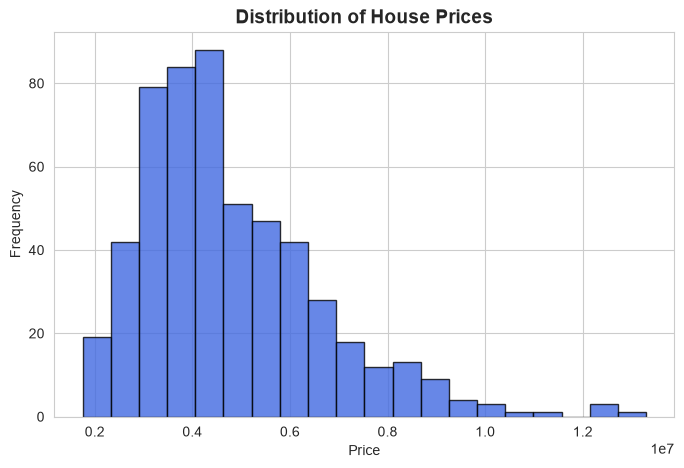

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_style("whitegrid")

plt.figure(figsize=(8,5))

plt.hist(
    df["price"],
    bins=20,
    color="royalblue",
    edgecolor="black",
    alpha=0.8
)

plt.title("Distribution of House Prices", fontsize=14, fontweight="bold")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

### Observation

"Most houses are concentrated within the lower and middle price ranges, while fewer houses exist in the higher price range. This indicates that the distribution of house prices is positively skewed."

## Correlation Heat Map

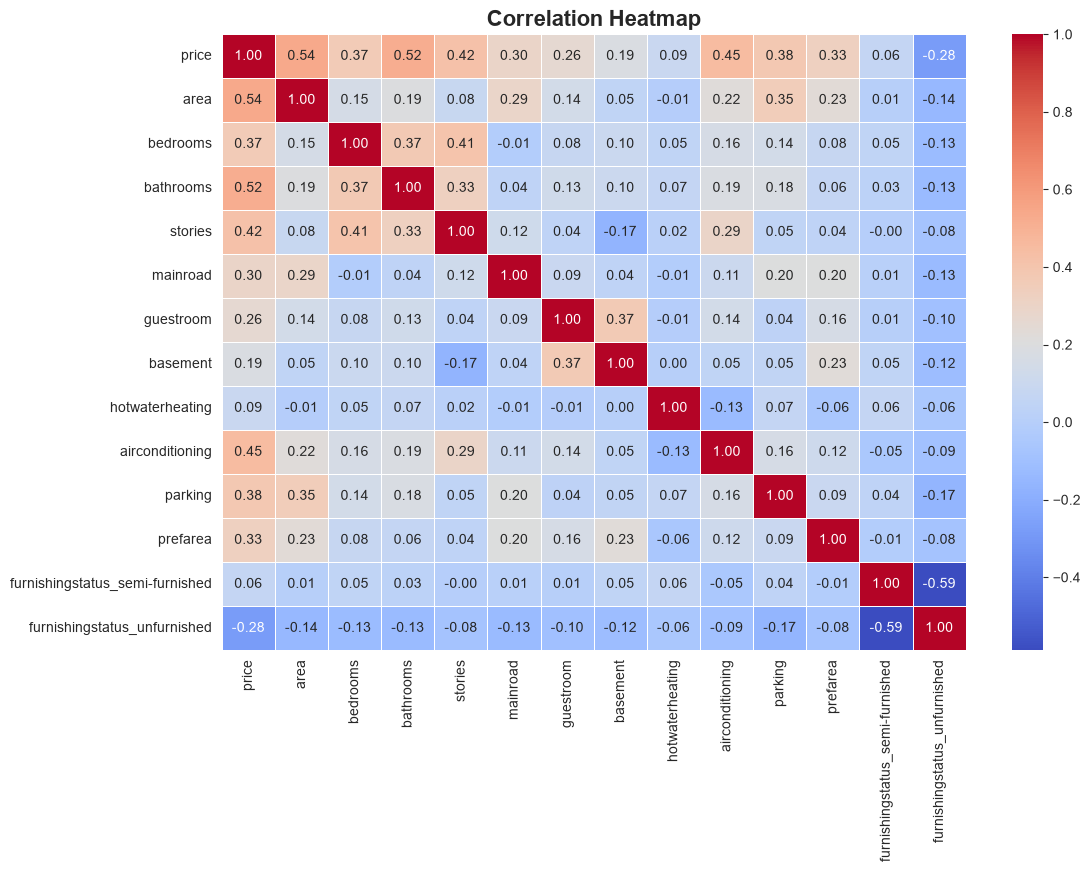

In [71]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title(
    "Correlation Heatmap",
    fontsize=16,
    fontweight="bold"
)

plt.show()

"The correlation heatmap shows that area (0.54) and bathrooms (0.52) have the strongest positive relationship with house price. "

## Actual vs Predicted Graph 

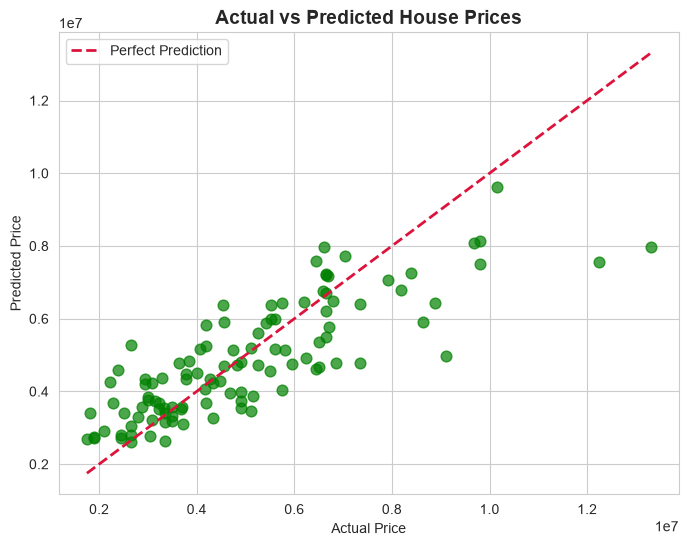

In [72]:
plt.figure(figsize=(8,6))

plt.scatter(
    ytest,
    lrpred,
    color="green",
    alpha=0.7,
    s=60
)

plt.plot(
    [ytest.min(), ytest.max()],
    [ytest.min(), ytest.max()],
    color="crimson",
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction"
)

plt.title(
    "Actual vs Predicted House Prices",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.legend()

plt.show()

## Feature Importance Graph

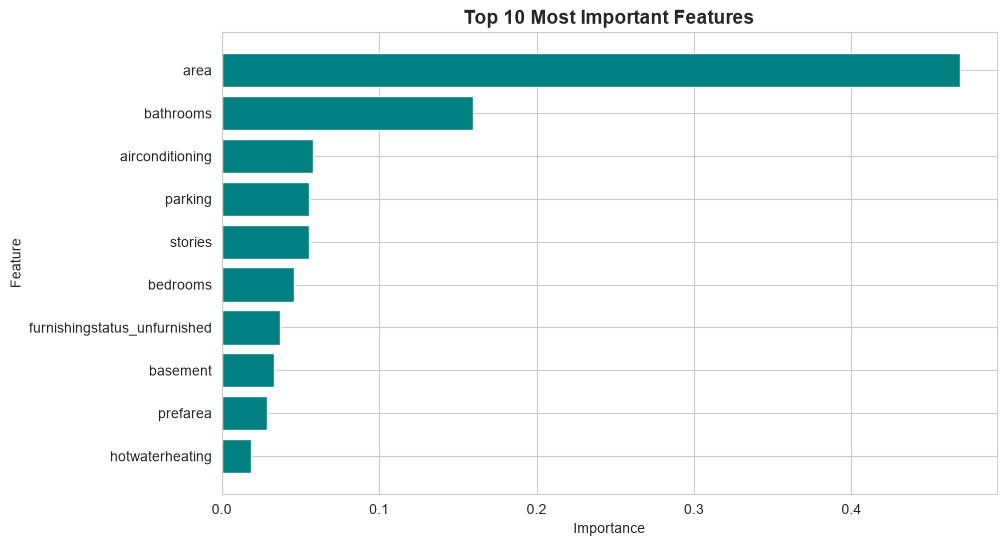

In [73]:
import pandas as pd

importance_df = pd.DataFrame({
    "Feature": xtrain.columns,
    "Importance": rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

plt.barh(
    importance_df["Feature"][:10],
    importance_df["Importance"][:10],
    color="teal"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title(
    "Top 10 Most Important Features",
    fontsize=14,
    fontweight="bold"
)

plt.gca().invert_yaxis()

plt.show()

## Overall Interpretation

These visualizations helped understand the distribution of house prices, the relationship between different features, and the performance of the prediction models.

The histogram and heatmap were useful for exploring the dataset, while the Actual vs Predicted plot and Feature Importance chart helped evaluate and interpret the machine learning models.

Together, they provide a good overview of both the data and the prediction results.

(I was not familiar with graphs so i seeked help from internet and did this work)

I did Additional experiments to explore any performance improvements:

1. Polynomial Regression was tested However, it achieved a lower R² score (~0.621) compared to the baseline Linear Regression model (~0.653).

2. Random Forest hyperparameters were tuned by modifying parameters such as the number of trees and tree depth. This resulted in only a marginal improvement, with the R² score increasing from ~0.612 to ~0.616.

3. Feature engineering was performed by creating additional features derived from the existing dataset. The best-performing engineered feature provided a small improvement, increasing the Linear Regression R² score to approximately 0.661.

These experiments provided informations that confirms the linear regression is by far the best .. 